# Bet Simulator
In questo notebook è contenuto il bet silumator del progetto. L'obiettivo è comprendere, utilizzando i vari modelli e impostando una metodologia di scommesse, quanto sarebbe il guadagno ottenuto da ciascun modello (compresa la baseline casuale).

## Metodologia di scommessa
L'approcio che utilizziamo è semplice, scommettere 10 euro su ogni partita, sulla classe consigliata dal nostro modello,

## Modelli

Adesso verifichiamo qual è il guadagno dei singoli modelli

## Importazione dei dataset e merge
Per prima cosa facciamo la merge tra i due dataset (scommesse e partite) importati, di modo da avere tutti i dati necessari.  

In [14]:
import pandas as pd
import difflib
import numpy as np

class Odds:

    __odds_dataset: pd.DataFrame
    __match_dataset: pd.DataFrame
    __merged_dataset: pd.DataFrame

    def __merge_dataset(self) -> None:

        # Normalizzazione delle date
        self.__match_dataset['Match_Date_Temp'] = pd.to_datetime(
            self.__match_dataset['Date'], 
            errors='coerce' 
        ).dt.date

        self.__odds_dataset['Odds_Date_Temp'] = pd.to_datetime(
            self.__odds_dataset['matchDate'], 
            format="%d-%m-%y %H:%M", 
            errors='coerce' 
        ).dt.date

        # Risoluzione dei nomi delle squadre
        self.__match_dataset = self.__match_dataset.dropna(subset=['Match_Date_Temp'])
        self.__odds_dataset = self.__odds_dataset.dropna(subset=['Odds_Date_Temp'])
        match_teams = pd.concat([self.__match_dataset['HomeTeam'], self.__match_dataset['AwayTeam']]).unique()
        odds_teams = pd.concat([self.__odds_dataset['homeTeam'], self.__odds_dataset['awayTeam']]).unique()

        team_mapping = {}
        for team in odds_teams:
            matches = difflib.get_close_matches(team, match_teams, n=1, cutoff=0.5)
            team_mapping[team] = matches[0] if matches else team

        self.__odds_dataset['homeTeam_Norm'] = self.__odds_dataset['homeTeam'].map(team_mapping)
        self.__odds_dataset['awayTeam_Norm'] = self.__odds_dataset['awayTeam'].map(team_mapping)

        # Affiancamento dei due dataset
        self.__merged_dataset = pd.merge(
            left=self.__match_dataset,
            right=self.__odds_dataset,
            left_on=['Match_Date_Temp', 'HomeTeam', 'AwayTeam'],
            right_on=['Odds_Date_Temp', 'homeTeam_Norm', 'awayTeam_Norm'],
            how='inner' 
        )

        # Pulizia delle colonne temporanee create per il merge
        col_rimuovere_match = ['Match_Date_Temp']
        col_rimuovere_odds = ['Odds_Date_Temp', 'homeTeam_Norm', 'awayTeam_Norm']
        
        # Le puliamo sia dai dataset originali che dal dataset finale
        self.__match_dataset.drop(columns=col_rimuovere_match, inplace=True, errors='ignore')
        self.__odds_dataset.drop(columns=col_rimuovere_odds, inplace=True, errors='ignore')
        self.__merged_dataset.drop(columns=col_rimuovere_match + col_rimuovere_odds, inplace=True, errors='ignore')

    def __init__(
            self,
            odds_dataframe_path: str,
            match_dataframe_path
    ) -> None:

        # Importazione e rimozione delle rows vuote 
        self.__odds_dataset = pd.read_csv(odds_dataframe_path)
        self.__match_dataset = pd.read_csv(match_dataframe_path)
        self.__odds_dataset = self.__odds_dataset.dropna()

        # Merge dei due dataset
        self.__merge_dataset()
        print(self.__merged_dataset.head(10))
    
    def backtest_distribution(self, season: int, n_simulations: int = 1000, seed: int | None = None) -> np.ndarray:
        """
        Ripete il backtest casuale n_simulations volte e mostra la distribuzione
        del guadagno/perdita ottenuto.
        Args:
            season: stagione su cui testare il modello (2024, 2025)
            n_simulations: numero di simulazioni da eseguire
            seed: seed opzionale per la riproducibilità
        Returns:
            array dei guadagni ottenuti in ogni simulazione
        """
        import matplotlib.pyplot as plt

        rng = np.random.default_rng(seed)
        selected_df = self.__merged_dataset[self.__merged_dataset["Season_x"] == f"{season}-{season+1}"]
        n = len(selected_df)
        if n == 0:
            return np.array([])

        result_map = {0: 'H', 1: 'D', 2: 'A'}
        odds_matrix = selected_df[['H', 'D', 'A']].to_numpy(dtype=float)
        results = selected_df['FTR'].to_numpy()
        cash_in = 10 * n

        predictions = rng.integers(0, 3, size=(n_simulations, n))
        pred_labels = np.vectorize(result_map.get)(predictions)
        correct = pred_labels == results[np.newaxis, :]

        row_idx = np.arange(n)
        selected_odds = odds_matrix[row_idx, predictions]

        earn_per_sim = np.sum(np.where(correct, 10 * selected_odds, 0.0), axis=1)
        profit = earn_per_sim - cash_in

        mean_profit = profit.mean()
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.hist(profit, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
        ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Break-even')
        ax.axvline(mean_profit, color='red', linestyle='-', linewidth=1.5, label=f'Media: {mean_profit:.2f}')
        ax.set_title(f'Distribuzione del guadagno - Stagione {season}-{season+1} ({n_simulations} simulazioni)')
        ax.set_xlabel('Guadagno netto')
        ax.set_ylabel('Frequenza')
        ax.legend()
        plt.tight_layout()
        plt.savefig('gauss_random.png', dpi=300, bbox_inches='tight')
        plt.show()

        return profit

         Date  HomeTeam    AwayTeam  FTHG  FTAG FTR   Season_x  \
0  2024-08-17     Genoa       Inter     2     2   D  2024-2025   
1  2024-08-17     Parma  Fiorentina     1     1   D  2024-2025   
2  2024-08-17    Empoli       Monza     0     0   D  2024-2025   
3  2024-08-17     Milan      Torino     2     2   D  2024-2025   
4  2024-08-18   Bologna     Udinese     1     1   D  2024-2025   
5  2024-08-18    Verona      Napoli     3     0   H  2024-2025   
6  2024-08-18  Cagliari        Roma     0     0   D  2024-2025   
7  2024-08-18     Lazio     Venezia     3     1   H  2024-2025   
8  2024-08-19     Lecce    Atalanta     0     4   A  2024-2025   
9  2024-08-19  Juventus        Como     3     0   H  2024-2025   

   Home_WinStreak  Away_WinStreak  Z_Home_Goals_Season  ...   O15   U15   O25  \
0               0               0                  0.0  ...  1.27  3.93  1.91   
1               0               0                  0.0  ...  1.29  3.75  1.99   
2               0             

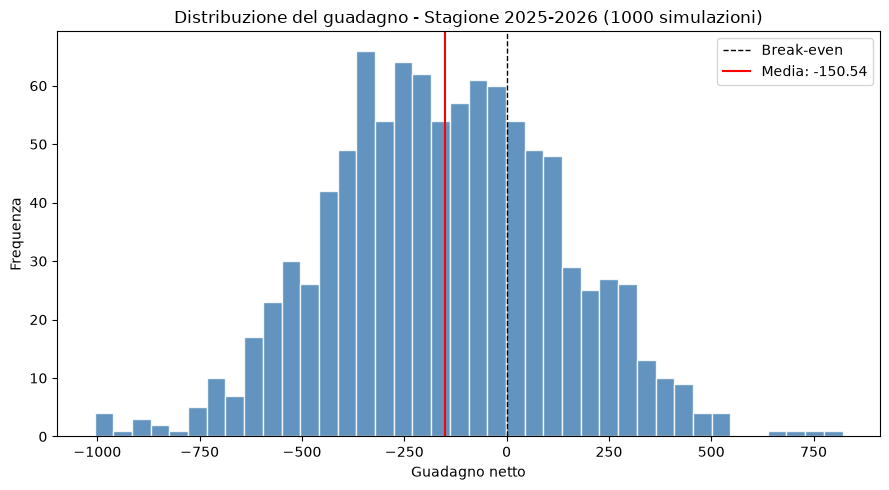

array([-8.6500e+01, -2.1700e+02,  1.8760e+02, -5.7830e+02, -9.9800e+01,
       -2.7120e+02,  5.0700e+01, -1.8100e+02, -3.5680e+02,  3.4750e+02,
        3.0200e+01, -4.6880e+02,  1.2770e+02,  3.7830e+02, -1.1650e+02,
       -5.2750e+02, -2.1600e+01, -3.9330e+02, -1.7500e+02, -2.6850e+02,
        8.3700e+01, -3.8280e+02, -3.4510e+02, -2.2330e+02, -2.4230e+02,
       -5.1540e+02,  1.2850e+02, -4.6310e+02, -4.7540e+02, -6.1900e+01,
        5.8900e+01, -6.9400e+02, -5.0090e+02,  2.1330e+02,  8.2800e+01,
        2.7770e+02, -8.7150e+02, -1.2430e+02, -5.7900e+01, -5.1200e+01,
       -2.6530e+02, -3.4540e+02, -4.7590e+02,  5.3000e+01, -2.5800e+02,
        1.2070e+02,  9.7900e+01, -4.2900e+01,  1.7770e+02, -5.7580e+02,
       -5.8260e+02, -3.3530e+02, -4.7380e+02,  1.0080e+02, -3.2550e+02,
        6.0400e+01,  8.9800e+01, -1.4810e+02, -3.2400e+01, -3.4420e+02,
        3.6060e+02, -9.4100e+01, -6.2100e+01, -2.1260e+02, -6.1400e+01,
       -2.4430e+02, -2.7720e+02, -1.2600e+02, -4.3870e+02, -6.79

In [15]:
# Dopo aver instanziato la classe e fatto il merge:
gestore_quote = Odds("static/odds/odds.csv", "static/da-result/result.csv")

gestore_quote.backtest_distribution(2025)